Phasor 생성기
--------------------

생성된 Phasor:
복소수 형태: 1.0000+0.0000j
크기: 1.0000
각도: 0.00°
실수부: 1.0000
허수부: 0.0000


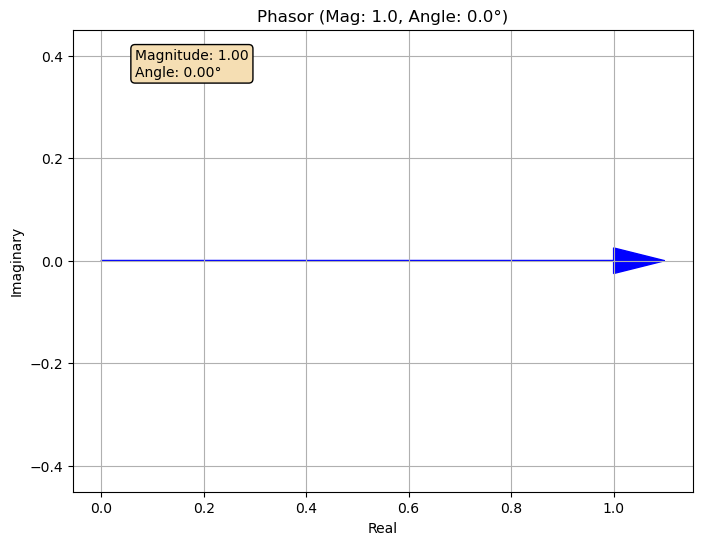

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def create_phasor(magnitude, angle_degrees):
    """
    크기와 각도(도)로 phasor를 생성하는 함수
    
    Parameters:
    magnitude (float): 크기
    angle_degrees (float): 각도 (도 단위)
    
    Returns:
    complex: 복소수 phasor
    """
    angle_radians = np.radians(angle_degrees)
    real_part = magnitude * np.cos(angle_radians)
    imag_part = magnitude * np.sin(angle_radians)
    return complex(real_part, imag_part)

def plot_phasor(phasor, title="Phasor"):
    """
    Phasor를 시각화하는 함수
    """
    plt.figure(figsize=(8, 6))
    plt.arrow(0, 0, phasor.real, phasor.imag, 
              head_width=0.05, head_length=0.1, fc='blue', ec='blue')
    plt.grid(True)
    plt.axis('equal')
    plt.xlabel('Real')
    plt.ylabel('Imaginary')
    plt.title(title)
    
    # 크기와 각도 표시
    magnitude = abs(phasor)
    angle = np.degrees(np.angle(phasor))
    plt.text(0.1, 0.9, f'Magnitude: {magnitude:.2f}\nAngle: {angle:.2f}°', 
             transform=plt.gca().transAxes, bbox=dict(boxstyle="round", facecolor='wheat'))
    plt.show()

# 사용자 입력받기
print("Phasor 생성기")
print("-" * 20)

# 크기와 각도 입력
magnitude = float(input("크기를 입력하세요: "))
angle_deg = float(input("각도를 입력하세요 (도 단위): "))

# Phasor 생성
phasor = create_phasor(magnitude, angle_deg)

# 결과 출력
print(f"\n생성된 Phasor:")
print(f"복소수 형태: {phasor:.4f}")
print(f"크기: {abs(phasor):.4f}")
print(f"각도: {np.degrees(np.angle(phasor)):.2f}°")
print(f"실수부: {phasor.real:.4f}")
print(f"허수부: {phasor.imag:.4f}")

# Phasor 시각화
plot_phasor(phasor, f"Phasor (Mag: {magnitude}, Angle: {angle_deg}°)")

In [ ]:
a=create_phasor(1, 0)+create_phasor(1, 30)+ create_phasor(1, 360)+


print(a+b)

(1.8660254037844388+0.49999999999999994j)


In [ ]:
import pandas as pd

def create_phasor_table(phasor_data):
    """
    여러 phasor 데이터를 테이블로 생성하는 함수
    
    Parameters:
    phasor_data (list): [(name, magnitude, angle), ...] 형태의 리스트
    
    Returns:
    DataFrame: phasor 테이블
    """
    data = []
    for name, mag, angle in phasor_data:
        phasor = create_phasor(mag, angle)
        data.append({
            'Name': name,
            'Magnitude': mag,
            'Angle(deg)': angle,
            'Real': phasor.real,
            'Imaginary': phasor.imag,
            'Complex': phasor
        })
    
    return pd.DataFrame(data)

def sum_phasors(phasor_table):
    """
    테이블의 모든 phasor를 합하는 함수
    
    Parameters:
    phasor_table (DataFrame): phasor 테이블
    
    Returns:
    complex: 합한 phasor
    """
    total_phasor = sum(phasor_table['Complex'])
    return total_phasor

def plot_multiple_phasors(phasor_table, show_sum=True):
    """
    여러 phasor와 그 합을 시각화하는 함수
    """
    plt.figure(figsize=(10, 8))
    
    # 개별 phasor들 그리기
    colors = plt.cm.tab10(np.linspace(0, 1, len(phasor_table)))
    
    for i, row in phasor_table.iterrows():
        phasor = row['Complex']
        plt.arrow(0, 0, phasor.real, phasor.imag, 
                  head_width=0.05, head_length=0.1, 
                  fc=colors[i], ec=colors[i], alpha=0.7,
                  label=f"{row['Name']} ({row['Magnitude']:.2f}∠{row['Angle(deg)']}°)")
    
    # 합 phasor 그리기 (옵션)
    if show_sum:
        sum_phasor = sum_phasors(phasor_table)
        plt.arrow(0, 0, sum_phasor.real, sum_phasor.imag, 
                  head_width=0.08, head_length=0.15, 
                  fc='red', ec='red', linewidth=3,
                  label=f"Sum ({abs(sum_phasor):.2f}∠{np.degrees(np.angle(sum_phasor)):.1f}°)")
    
    plt.grid(True)
    plt.axis('equal')
    plt.xlabel('Real')
    plt.ylabel('Imaginary')
    plt.title('Multiple Phasors and Their Sum')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# 사용자로부터 테이블 데이터 입력받기
print("여러 Phasor 합 계산기")
print("=" * 30)

num_phasors = int(input("입력할 phasor 개수를 입력하세요: "))

phasor_data = []
for i in range(num_phasors):
    print(f"\n{i+1}번째 Phasor:")
    name = input(f"  이름: ")
    magnitude = float(input(f"  크기: "))
    angle = float(input(f"  각도 (도): "))
    phasor_data.append((name, magnitude, angle))

# Phasor 테이블 생성
phasor_table = create_phasor_table(phasor_data)

print("\n" + "="*50)
print("Phasor 테이블:")
print("="*50)
print(phasor_table.round(4))

# Phasor 합 계산
sum_result = sum_phasors(phasor_table)

print("\n" + "="*30)
print("Phasor 합 결과:")
print("="*30)
print(f"복소수 형태: {sum_result:.4f}")
print(f"크기: {abs(sum_result):.4f}")
print(f"각도: {np.degrees(np.angle(sum_result)):.2f}°")
print(f"실수부: {sum_result.real:.4f}")
print(f"허수부: {sum_result.imag:.4f}")

# 시각화
plot_multiple_phasors(phasor_table, show_sum=True)

In [ ]:
# 예시: 3상 전력시스템의 전압 phasor 합 계산
print("예시: 3상 전력시스템 전압 Phasor")
print("="*40)

# 3상 전압 데이터 (120도씩 차이)
example_phasors = [
    ("Va", 220, 0),      # A상 전압
    ("Vb", 220, -120),   # B상 전압  
    ("Vc", 220, 120)     # C상 전압
]

# 테이블 생성 및 출력
example_table = create_phasor_table(example_phasors)
print("\n3상 전압 테이블:")
print(example_table.round(4))

# 합 계산
example_sum = sum_phasors(example_table)
print(f"\n3상 전압의 합:")
print(f"복소수: {example_sum:.4f}")
print(f"크기: {abs(example_sum):.4f}")
print(f"각도: {np.degrees(np.angle(example_sum)):.2f}°")
print("(이상적인 3상 시스템에서는 합이 0이 되어야 함)")

# 시각화
plot_multiple_phasors(example_table)

# Phasor 계산기 사용법 요약

이 노트북은 다음과 같은 phasor 계산 기능을 제공합니다:

## 🔧 주요 기능

### 1. 단일 Phasor 생성 및 시각화
- `create_phasor(magnitude, angle_degrees)`: 크기와 각도로 phasor 생성
- `plot_phasor(phasor, title)`: 단일 phasor 시각화

### 2. 테이블 형태 다중 Phasor 처리
- `create_phasor_table(phasor_data)`: 여러 phasor를 테이블로 생성
- `sum_phasors(phasor_table)`: 테이블의 모든 phasor 합 계산
- `plot_multiple_phasors(phasor_table)`: 다중 phasor 및 합 시각화

### 3. CSV 파일 입출력
- `create_sample_csv()`: 샘플 CSV 파일 생성
- `load_phasors_from_csv(filename)`: CSV에서 phasor 데이터 읽기
- `export_phasor_results(table, sum_result)`: 결과를 CSV로 저장

## 📊 CSV 파일 형식

```csv
Name,Magnitude,Angle_deg
I1,10.0,0
I2,15.0,30
V1,220.0,-45
```

## 🎯 사용 예시

1. **수동 입력**: 셀 3에서 직접 phasor 개수와 값을 입력
2. **예시 데이터**: 셀 4에서 3상 전력시스템 예시 확인
3. **CSV 사용**: 셀 5에서 파일 기반 처리 방법 확인

In [ ]:
# 빠른 테스트용 - 간단한 phasor 합 계산
print("빠른 Phasor 합 계산 테스트")
print("="*35)

# 간단한 예시 데이터
quick_test_data = [
    ("전압 V1", 100, 0),      # 100V ∠0°
    ("전압 V2", 100, 90),     # 100V ∠90°
    ("전류 I1", 5, -30),      # 5A ∠-30°
]

# 테이블 생성
quick_table = create_phasor_table(quick_test_data)
print("\n테스트 Phasor 테이블:")
print(quick_table.round(3))

# 합 계산
quick_sum = sum_phasors(quick_table)
print(f"\nPhasor 합 결과:")
print(f"  크기: {abs(quick_sum):.3f}")
print(f"  각도: {np.degrees(np.angle(quick_sum)):.1f}°")
print(f"  복소수: {quick_sum:.3f}")

# 개별 phasor 정보 출력
print(f"\n개별 Phasor 정보:")
for i, row in quick_table.iterrows():
    print(f"  {row['Name']}: {row['Magnitude']:.1f}∠{row['Angle(deg)']:.0f}° = {row['Complex']:.3f}")

# 시각화
plot_multiple_phasors(quick_table, show_sum=True)